# One array, two machines

> Own an array, fill it, and move it to a GPU and back -- with the same
> two lines of code whether a GPU is there or not.

**Time:** ~6 min · **Runs on:** CPU, GPU switch · **You need:** a C++23
compiler (no CUDA toolchain required)

In [1]:
%run ../_shared/setup.py

running on: cpu


*(Code cells here run through `run_cpp()`, a tiny compile-and-run helper defined once in `_shared/cpp_harness.py`.)*

`aether::Array<T, Es...>` owns a batch of *samples* -- `Es...` is the
per-sample shape, so `Array<double, 3>` holds `n` three-component
vectors, one allocation for the whole batch:

In [2]:
print(run_cpp(r"""
    aether::Array<double, 3> arr(6);      // 6 samples, 3 components each
    std::printf("samples=%zu size=%zu\n", arr.samples(), arr.size());
"""))

samples=6 size=18



`size()` is `samples() * 3`, the total scalar count.

`.hostView()` hands back a `View`, indexed `(component, sample)`, to
read and write each value:

In [3]:
print(run_cpp(r"""
    aether::Array<double, 3> arr(6);
    auto v = arr.hostView();
    for (std::size_t i = 0; i < arr.samples(); ++i)
        for (std::size_t c = 0; c < 3; ++c)
            v(c, i) = static_cast<double>(c * 10 + i);
    std::printf("v(1,2)=%g\n", v(1, 2));
"""))

v(1,2)=12



`v(1, 2)` reads component 1 of sample 2 -- the value highlighted
below.

## What you will build (the picture)

`View`'s layout is structure-of-arrays: component `c`'s samples sit in
one contiguous block, not interleaved sample-by-sample. The picture
below shows that for the array above, with `v(1, 2)` highlighted:

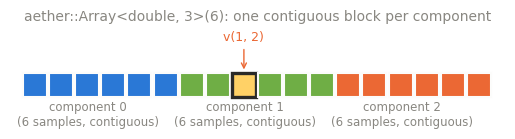

In [4]:
import matplotlib.pyplot as plt
plot_style()

fig, ax = plt.subplots(figsize=(6.4, 2.3))
N = 6
colors = ["#2a78d6", "#6fae45", "#eb6834"]
highlight = (1, 2)  # (component, sample) -- the v(1, 2) read above
for comp in range(3):
    for i in range(N):
        is_hl = (comp, i) == highlight
        face = "#ffd166" if is_hl else colors[comp]   # a colour no component uses
        edge = "#2a2a28" if is_hl else "#fcfcfb"
        lw = 2.4 if is_hl else 1.5
        ax.add_patch(plt.Rectangle((comp * N + i, 0), 0.92, 0.92, facecolor=face,
                                    edgecolor=edge, linewidth=lw, zorder=2))
    ax.text(comp * N + N / 2 - 0.5, -0.15, f"component {comp}\n({N} samples, contiguous)",
            ha="center", va="top", color="#898781", fontsize=8.5)
hc, hi = highlight
ax.annotate("v(1, 2)", xy=(hc * N + hi + 0.46, 0.95), xytext=(hc * N + hi + 0.46, 2.15),
            ha="center", color="#eb6834", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="#eb6834"))
ax.set_xlim(-0.5, 3 * N + 0.5)
ax.set_ylim(-1.1, 2.6)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("aether::Array<double, 3>(6): one contiguous block per component",
             color="#898781", fontsize=10)
plt.show()

Three blocks of six values each -- one per component -- is what lets a
GPU read one component across many threads in a single coalesced
transaction (see [Host vs device code](../host_vs_device.rst)).

On a CUDA build, an `Array` owns two buffers: a host copy and a device
copy.

`.upload()`/`.download()` move bytes between them. In a CPU-only build
there is only one buffer, so the same two calls are harmless no-ops:

In [5]:
print(run_cpp(r"""
    aether::Array<double, 1> a(1);
    a.hostView()(0, 0) = 42.0;
    a.upload();     // CPU-only build: no device copy, so this is a no-op
    a.download();   // the same call either way
    std::printf("still here: %g\n", a.hostView()(0, 0));
"""))

still here: 42



The value survives unchanged -- on a CUDA build the exact same two
lines move it to the GPU and back.

## What just happened

- `aether::Array<T, Es...>` owns its memory; `.hostView()` indexes it
  `(component, sample)`.
- The layout is structure-of-arrays: every component's samples are one
  contiguous block.
- `.upload()`/`.download()` move bytes to and from the device; in a
  CPU-only build they are no-ops, so the exact same source line is what
  a CUDA build also runs.

## Try this

Change `Array<double, 3>` to `Array<double, 4>` and re-run the first
cell: `size()` grows to `4 * 6`.

## Next

[Expressions without temporaries](02_expressions_without_temporaries) --
compose several operators and watch them still cost exactly one pass
over the data. *Deeper:* [Views and items](../views_and_items.rst),
[Memory ownership](../memory_ownership.rst) for the full `Chunk`/`View`
picture this tutorial only sampled.

## Going deeper (optional): proving the layout from scratch

The SoA layout above is checkable directly, using the lower-level
`Chunk`/`View` pair `Array` wraps: `Chunk::allocate` takes a `Device`
(`kDLCPU` here, the DLPack tag for "on the host") and a byte count;
`make_view<T, C, N>` wraps it as a view with `C` compile-time components
and `N` samples (`aether::dyn` marks a dimension as runtime-sized, the
same way `Array`'s own sample count is):

In [6]:
print(run_cpp(r"""
    constexpr std::size_t C = 3, N = 6;
    auto chunk = aether::Chunk::allocate(aether::Device(kDLCPU), C * N * sizeof(double));
    auto v = aether::make_view<double, C, aether::dyn>(chunk, N);

    bool soa_holds = true;
    for (std::size_t c = 0; c < C; ++c)
        for (std::size_t i = 0; i < N; ++i)
            soa_holds &= (&v(c, i) - v.data()) == static_cast<std::ptrdiff_t>(c * N + i);

    std::printf("SoA identity holds for every (c,i): %s\n", soa_holds ? "true" : "false");
"""))

SoA identity holds for every (c,i): true

